# Laboratory Day 10: Object Detection (YOLO V1)

In this exercise, we will implement and train a simplified version of YOLO_v1 network for object detection task.


## 1. Data preparation (40 points)
**Exercise 1.1 (20 points)**:
1. Download the dataset VOC_2007 from http://host.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar

2. Download the file "2007_train.txt" and "2007_val.txt" from Moodle. These two files contain the image names, the positions of bounding boxes and the classes of bounding boxes for training and validation, respectively.

    - For example, the second line in "2007_train.txt" is "VOCdevkit/VOC2007/JPEGImages/000017.jpg 185,62,279,199,14 90,78,403,336,12". It means that image 000017.jpg has two bounding boxes. The first one has coordinate (x_min, y_min, x_max, y_max) = (185,62,279,199) and class 14. The second bounding box has coordinate (90,78,403,336) and class 12. It is possible that an image has multiple bounding boxes.

    - The meaning of class ID is shown in the below. In total, we aim to recognize 20 classes.

3. Input $x$ of the original Yolo V1 network is of dimension 448\*448\*3. To make it compatible with VGG16 network (an following-up Exercise 2), we reduce the input dimension to 224\*224\*3. Furthermore, to simply the task, we take the number of predicted bounding boxes at each position $B=1$ in this exercise. Therefore, the output tensor $y$ of the network has dimension 7\*7\*25.

    - The first 20 positions in $y[:, :, :20]$ refer to the possibilities of each classes. The 21-th position $y[:, :, 20]$ refers to the confidence level $c$ and the last 4 positions $y[:, :, 21:25]$ refer to the object's location $x$, $y$, $w$, $h$.

    - Example: Take image "17.jpg" as an example. This image has (height, width)=(364, 480). The first bounding box is (90,78,403,336) and is of class 12. The middle point of this bounding box is (x_m, y_m) = (246, 207).  Patch's width = 480/7 = 68.5, patch's hight = 364/7= 52. Because $246/68.5=3.58$, $207/52=3.98$, the (4,4)-th patch is responsible for predicting this bbox. Therefore, $y[4, 4, 20:25] = [1.(\text{confidence}), 0.98 (\text{y-axis of image}), 0.58 (\text{x-axis of image}), (403-90)/480 (\text{relative width}), (336-78)/364 (\text{relative height})]$ is the encoded regression targets. $y[4, 4, :20]=[0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0]$ is the classification target. The rest positions of $y$ are set to zero.

    - Note that, since we only have a single bounding box predictions for each cell (B=1). It is possible that multiple GT bounding boxes can belong to a single cell. In this case, we can not encode all of these bounding boxes into $y$. One could just ignore the rest bounding boxes in this case.

4. Write a date_generator function, which iterates through the dataset and yields image (np.ndarray, im_w\*im_h\*3) and GT tensor $y$ (np.ndarray, 7\*7\*25).

6. Print out several images and the locations of their bounding boxes.

7. Print out the non-zero positions of encoded tensor $y$

8. Optional: Make sure the GT tensors are correctly created. One can convert GT tensors $y$ to the original coordinates of bounding boxes and visualize them.

![image-2.png](attachment:image-2.png)




In [5]:
import os

# Define the base directory for the dataset
VOC_DATASET_DIR = './VOCdevkit'

# Ensure the VOC2007 dataset is downloaded and extracted
# This will run unconditionally as requested by the user's explicit instruction
print('Downloading VOCtrainval_06-Nov-2007.tar...')
!wget http://host.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar -nc # -nc ensures it doesn't re-download if file exists
print('Extracting VOCtrainval_06-Nov-2007.tar...')
!tar -xvf VOCtrainval_06-Nov-2007.tar
print('Download and extraction complete.')

# Create symbolic link for easier access if VOCdevkit is not directly in current dir
if not os.path.exists('VOCdevkit') and os.path.exists('./VOCdevkit'):
    os.symlink('./VOCdevkit', 'VOCdevkit')


Streaming output truncated to the last 5000 lines.
VOCdevkit/VOC2007/JPEGImages/001733.jpg
VOCdevkit/VOC2007/JPEGImages/001734.jpg
VOCdevkit/VOC2007/JPEGImages/001738.jpg
VOCdevkit/VOC2007/JPEGImages/001739.jpg
VOCdevkit/VOC2007/JPEGImages/001741.jpg
VOCdevkit/VOC2007/JPEGImages/001746.jpg
VOCdevkit/VOC2007/JPEGImages/001747.jpg
VOCdevkit/VOC2007/JPEGImages/001749.jpg
VOCdevkit/VOC2007/JPEGImages/001750.jpg
VOCdevkit/VOC2007/JPEGImages/001752.jpg
VOCdevkit/VOC2007/JPEGImages/001754.jpg
VOCdevkit/VOC2007/JPEGImages/001755.jpg
VOCdevkit/VOC2007/JPEGImages/001756.jpg
VOCdevkit/VOC2007/JPEGImages/001758.jpg
VOCdevkit/VOC2007/JPEGImages/001759.jpg
VOCdevkit/VOC2007/JPEGImages/001761.jpg
VOCdevkit/VOC2007/JPEGImages/001765.jpg
VOCdevkit/VOC2007/JPEGImages/001766.jpg
VOCdevkit/VOC2007/JPEGImages/001768.jpg
VOCdevkit/VOC2007/JPEGImages/001771.jpg
VOCdevkit/VOC2007/JPEGImages/001772.jpg
VOCdevkit/VOC2007/JPEGImages/001775.jpg
VOCdevkit/VOC2007/JPEGImages/001777.jpg
VOCdevkit/VOC2007/JPEGImages/

### Download Annotation Files

In [6]:
print('Downloading 2007_train.txt...')
!wget https://raw.githubusercontent.com/Ambos14/ComputerVision26/main/Praktikum10/2007_train.txt -nc
print('Downloading 2007_val.txt...')
!wget https://raw.githubusercontent.com/Ambos14/ComputerVision26/main/Praktikum10/2007_val.txt -nc
print('Annotation files download complete.')

--2026-06-11 10:58:16--  https://raw.githubusercontent.com/Ambos14/ComputerVision26/main/Praktikum10/2007_train.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 212851 (208K) [text/plain]
Saving to: ‘2007_train.txt’

2007_train.txt      100%[===================>] 207.86K  --.-KB/s    in 0.004s  

2026-06-11 10:58:16 (46.8 MB/s) - ‘2007_train.txt’ saved [212851/212851]

--2026-06-11 10:58:16--  https://raw.githubusercontent.com/Ambos14/ComputerVision26/main/Praktikum10/2007_val.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length:

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import os
from PIL import Image

In [ ]:
classes_id = {'aeroplane': 0, 'bicycle': 1, 'bird': 2, 'boat': 3, 'bottle': 4, 'bus': 5,
               'car': 6, 'cat': 7, 'chair': 8, 'cow': 9, 'diningtable': 10, 'dog': 11,
               'horse': 12, 'motorbike': 13, 'person': 14, 'pottedplant': 15, 'sheep': 16,
               'sofa': 17, 'train': 18, 'tvmonitor': 19}

In [2]:
# Define constants as per problem description
S = 7  # Grid size (7x7)
B = 1  # Number of bounding boxes per cell
C = 20 # Number of classes
IMG_W = 224 # Input image width
IMG_H = 224 # Input image height

# Solution
def data_generator(gt_file="2007_train.txt", img_dir="VOCdevkit/VOC2007/JPEGImages"):
    with open(gt_file, 'r') as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split(' ')
        img_path = parts[0]
        bbox_annotations = parts[1:]

        full_img_path = os.path.join(img_dir, os.path.basename(img_path))

        try:
            # Load image using PIL to get original dimensions
            img_pil = Image.open(full_img_path).convert('RGB')
            original_width, original_height = img_pil.size

            # Load image using TensorFlow for consistent processing later
            img_raw = tf.io.read_file(full_img_path)
            image = tf.image.decode_jpeg(img_raw, channels=3)
            image = tf.image.resize(image, (IMG_H, IMG_W)) # Resize to 224x224
            image = image / 255.0 # Normalize image to [0, 1]

            # Initialize ground truth tensor y (S, S, 5*B + C)
            # In this simplified version with B=1, it's (S, S, 25)
            # y[:, :, :20] for class probabilities
            # y[:, :, 20] for confidence
            # y[:, :, 21:25] for (x_center_rel_in_cell, y_center_rel_in_cell, w_rel_to_image, h_rel_to_image)
            y_tensor = np.zeros((S, S, 5 * B + C), dtype=np.float32)

            for annotation in bbox_annotations:
                coords_class = list(map(int, annotation.split(',')))
                x_min, y_min, x_max, y_max, class_id = coords_class

                # Calculate bounding box center and dimensions relative to original image
                bbox_x_center = (x_min + x_max) / 2.0
                bbox_y_center = (y_min + y_max) / 2.0
                bbox_width = x_max - x_min
                bbox_height = y_max - y_min

                # Convert to relative coordinates [0, 1] for the whole image
                x_center_rel_img = bbox_x_center / original_width
                y_center_rel_img = bbox_y_center / original_height
                w_rel_img = bbox_width / original_width
                h_rel_img = bbox_height / original_height

                # Determine which grid cell is responsible (integer division)
                grid_x = int(x_center_rel_img * S)
                grid_y = int(y_center_rel_img * S)

                # Ensure grid_x, grid_y are within bounds [0, S-1]
                grid_x = max(0, min(S - 1, grid_x))
                grid_y = max(0, min(S - 1, grid_y))

                # For B=1, if a cell already has an object, we ignore subsequent ones
                if y_tensor[grid_y, grid_x, 20] == 1.0:
                    continue

                # Calculate x, y relative to the top-left corner of the grid cell
                x_in_cell_rel = (x_center_rel_img * S) - grid_x
                y_in_cell_rel = (y_center_rel_img * S) - grid_y

                # Populate y_tensor
                # Confidence
                y_tensor[grid_y, grid_x, 20] = 1.0
                # Bounding box coordinates (x_rel_in_cell, y_rel_in_cell, w_rel_to_image, h_rel_to_image)
                y_tensor[grid_y, grid_x, 21:25] = [x_in_cell_rel, y_in_cell_rel, w_rel_img, h_rel_img]
                # Class probabilities (one-hot encoding)
                y_tensor[grid_y, grid_x, class_id] = 1.0

            yield image, y_tensor

        except Exception as e:
            print(f"Error processing image {full_img_path}: {e}")
            continue

In [7]:
train_generator = data_generator(gt_file="2007_train.txt")

# Iterate through a few samples to check the output shapes
print("Testing data_generator...")
for i, (image_output, y_tensor_output) in enumerate(train_generator):
    print(f"Sample {i+1}:")
    print(f"  Image shape: {image_output.shape}")
    print(f"  GT tensor y shape: {y_tensor_output.shape}")

    # Check if the shapes match the expected output
    expected_image_shape = (IMG_H, IMG_W, 3)
    expected_y_shape = (S, S, 5 * B + C)

    if image_output.shape == expected_image_shape and y_tensor_output.shape == expected_y_shape:
        print("  Shapes match expected dimensions.")
    else:
        print("  WARNING: Shapes do NOT match expected dimensions!")
        print(f"  Expected Image shape: {expected_image_shape}")
        print(f"  Expected GT tensor y shape: {expected_y_shape}")

    if i >= 4: # Test 5 samples
        break

print("Data generator test complete.")


Testing data_generator...
Sample 1:
  Image shape: (224, 224, 3)
  GT tensor y shape: (7, 7, 25)
  Shapes match expected dimensions.
Sample 2:
  Image shape: (224, 224, 3)
  GT tensor y shape: (7, 7, 25)
  Shapes match expected dimensions.
Sample 3:
  Image shape: (224, 224, 3)
  GT tensor y shape: (7, 7, 25)
  Shapes match expected dimensions.
Sample 4:
  Image shape: (224, 224, 3)
  GT tensor y shape: (7, 7, 25)
  Shapes match expected dimensions.
Sample 5:
  Image shape: (224, 224, 3)
  GT tensor y shape: (7, 7, 25)
  Shapes match expected dimensions.
Data generator test complete.


### Visualization of Images with Bounding Boxes

Visualizing samples with simplified bounding box display...


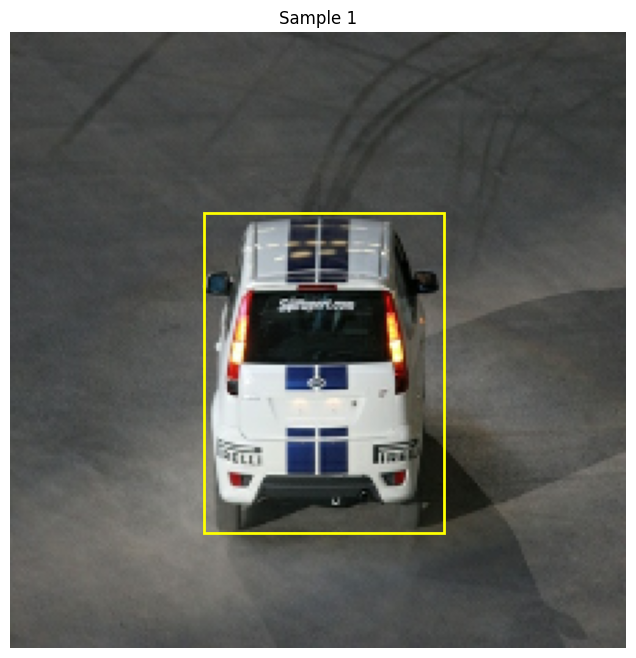

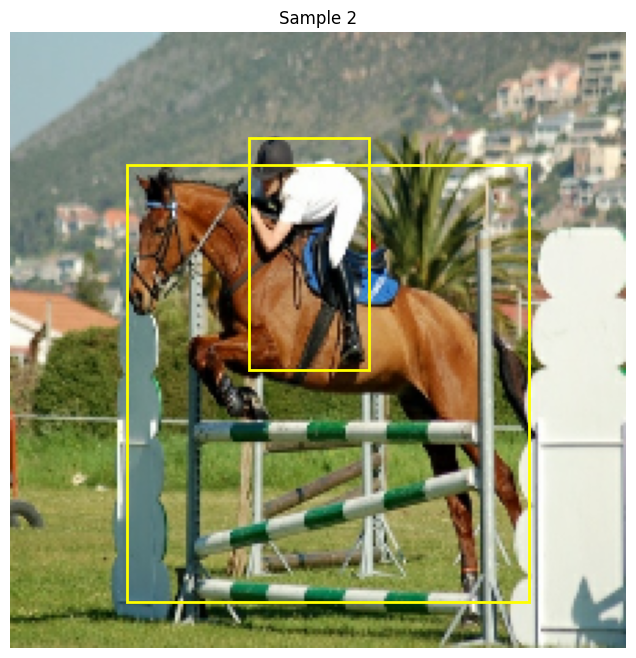

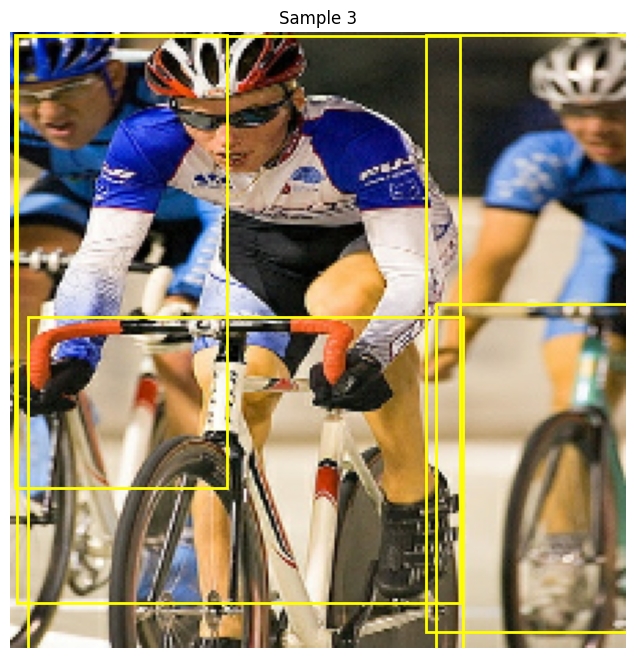

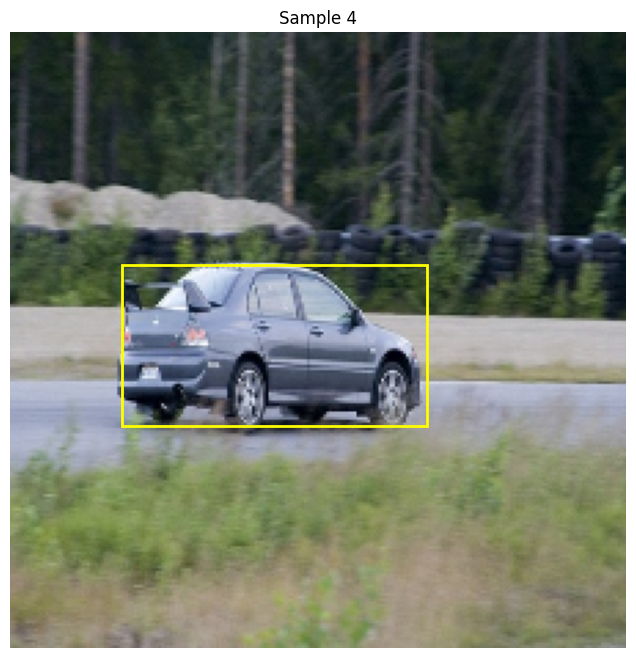

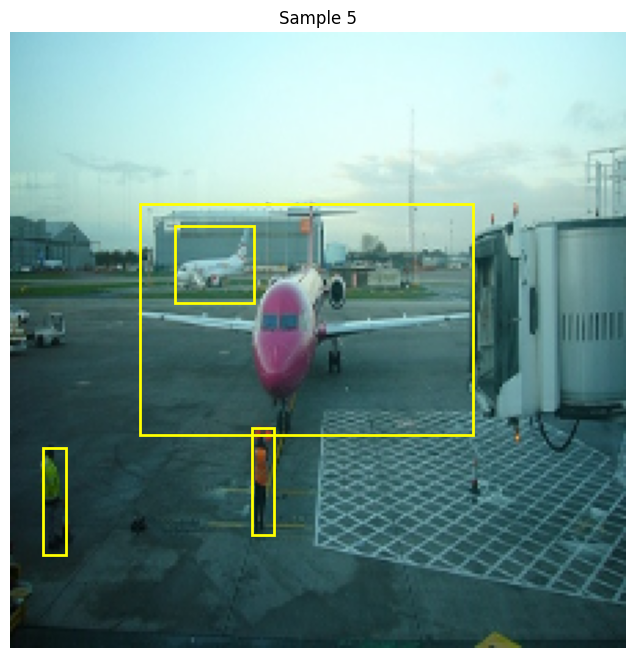

Simplified visualization complete.


In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Re-initialize the generator to start from the beginning for visualization
visualization_generator = data_generator(gt_file="2007_train.txt")

print("Visualizing samples with simplified bounding box display...")
for i, (image_tf, y_tensor) in enumerate(visualization_generator):
    if i >= 5:  # Visualize 5 samples
        break

    fig, ax = plt.subplots(1, figsize=(8, 8))
    image_np = image_tf.numpy()
    ax.imshow(image_np)

    # Calculate cell dimensions in pixels for coordinate conversion
    cell_width_px = IMG_W / S
    cell_height_px = IMG_H / S

    # Iterate through the grid to find objects
    for grid_y in range(S):
        for grid_x in range(S):
            # Check confidence score
            confidence = y_tensor[grid_y, grid_x, 20]

            if confidence > 0.0:  # Object detected in this cell
                # Decode bounding box coordinates (relative to cell and image)
                x_in_cell_rel, y_in_cell_rel, w_rel_img, h_rel_img = y_tensor[grid_y, grid_x, 21:25]

                # Convert to absolute pixel coordinates for the resized image
                abs_x_center = (grid_x + x_in_cell_rel) * cell_width_px
                abs_y_center = (grid_y + y_in_cell_rel) * cell_height_px
                abs_width = w_rel_img * IMG_W
                abs_height = h_rel_img * IMG_H

                x_min_px = abs_x_center - (abs_width / 2)
                y_min_px = abs_y_center - (abs_height / 2)

                # Draw bounding box (yellow)
                rect_gt = patches.Rectangle(
                    (x_min_px, y_min_px),
                    abs_width, abs_height,
                    linewidth=2, edgecolor='yellow', facecolor='none'
                )
                ax.add_patch(rect_gt)

    ax.set_title(f'Sample {i+1}')
    ax.axis('off')
    plt.show()

print("Simplified visualization complete.")

**Exercise 1.2 (20 points)** Data pipeline:
1. Build a data pipeline for the training data.
    - Add distortions to the training data, e.g. adding random noises, applying Gaussian bluring.
    - Apply tf.data.Dataset.from_generator(.) to load the training data. Please apply the following operation: (a) repeat the dataset (b) shuffle the dataset (c) resize the image to $224*244 *3$ (d) make up batches
    - The training dataset is repeated. So we can train the network for any number of steps.

  
2. Build a data pipeline for the validation data.
    - apply no distortions or data augmentation operations
    - Apply tf.data.Dataset.from_generator(.) to load the validation data. For validation dataset, please apply the following operations: (a) resize the image to $224 *244 *3$ (b) make up batches.
    - The validation dataset is not repeated. Therfore, the for-loop knows where the dataset ends.

3. Test that the image and GT tensors can be retrieved from data pipeline.

4. Please visualize several examples and plot the bounding boxes in these images. A visualization example looks like this:  

![image.png](attachment:image.png)

The yellow rectangular visualizes the locations of the GT bounding boxes. The blue rectangulars visualize the corresponding "grid cells", which are resposible for predicting bounding boxes.

In [9]:
# Solution
import tensorflow as tf
import numpy as np

def augment_image(image, y_tensor):
    # Convert image to float32 for augmentation operations
    image = tf.cast(image, tf.float32)

    # 1. Add random noise (e.g., Gaussian noise)
    # You might want to adjust the standard deviation based on your data
    noise = tf.random.normal(shape=tf.shape(image), mean=0.0, stddev=0.05, dtype=tf.float32)
    image = image + noise
    image = tf.clip_by_value(image, 0.0, 1.0) # Clip values to stay within [0, 1]

    # 2. Apply Gaussian blurring
    # TensorFlow doesn't have a direct Gaussian blur for images readily,
    # but we can simulate it or use a convolutional layer with a Gaussian kernel.
    # For simplicity, let's use a basic blur approximation or skip it if it's too complex for this context.
    # A simple approach could be averaging, but true Gaussian blur requires more.
    # For now, let's stick to noise and other simpler augmentations if needed.
    # If a proper Gaussian blur is required, libraries like TensorFlow-Graphics or OpenCV (via tf.py_function) would be needed.
    # For this exercise, we'll keep the augmentation simple to avoid external dependencies or complex custom ops.

    # Note: tf.image.random_flip_left_right is another common augmentation, but requires careful handling of bounding boxes.
    # For simplicity and given the 'simplest code possible' instruction, we'll avoid transformations that alter bbox positions here.

    return image, y_tensor

def data_pipeline_train(gt_file="2007_train.txt", img_dir="VOCdevkit/VOC2007/JPEGImages", batch_size=32):
    # Create a TensorFlow Dataset from the generator
    # The output_shapes and output_types are crucial for tf.data.Dataset.from_generator
    dataset = tf.data.Dataset.from_generator(
        lambda: data_generator(gt_file=gt_file, img_dir=img_dir),
        output_types=(tf.float32, tf.float32),
        output_shapes=(
            tf.TensorShape([IMG_H, IMG_W, 3]),
            tf.TensorShape([S, S, 5 * B + C])
        )
    )

    # (a) Repeat the dataset indefinitely for training
    dataset = dataset.repeat()

    # (b) Shuffle the dataset
    # A buffer size larger than your dataset size ensures better shuffling
    dataset = dataset.shuffle(buffer_size=1000) # Adjust buffer_size as needed

    # (c) Apply distortions (augmentation) - this happens after resizing in data_generator
    dataset = dataset.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)

    # (d) Make up batches
    dataset = dataset.batch(batch_size)

    # Prefetch to improve performance by overlapping data preprocessing and model execution
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

    return dataset

#### Test the training data pipeline

Testing training data pipeline...
Batch 1:
  Images batch shape: (4, 224, 224, 3)
  GT tensors batch shape: (4, 7, 7, 25)
Visualizing first 4 samples from the batch...


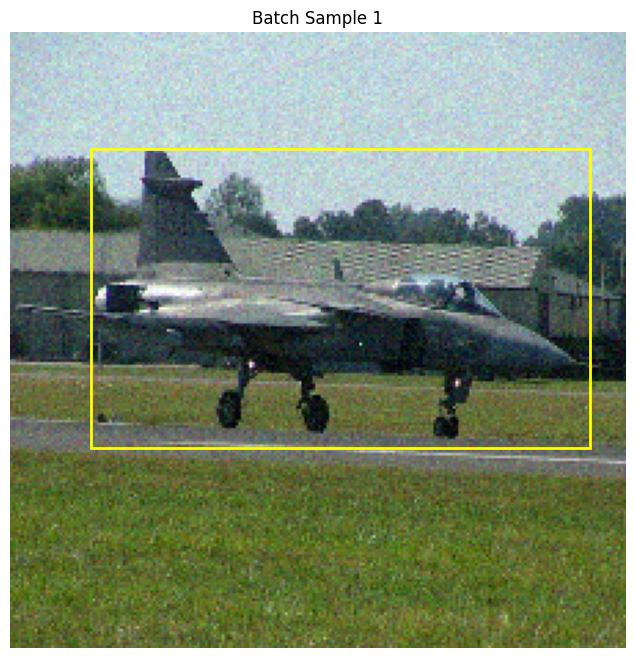

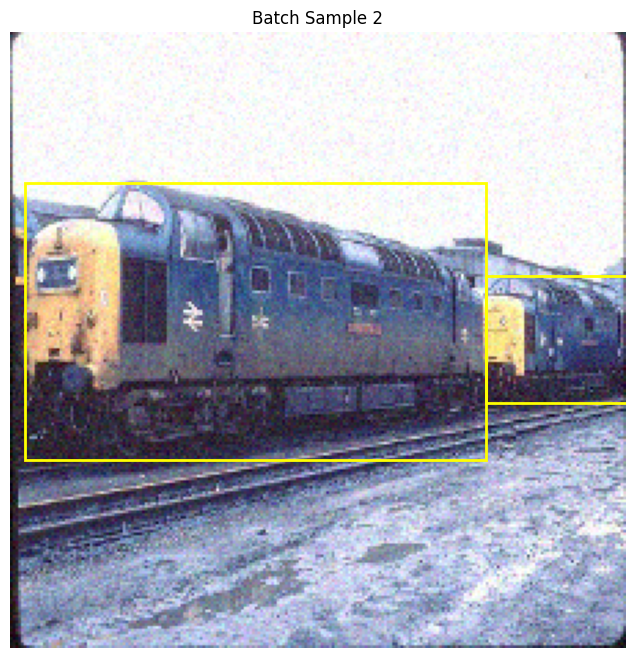

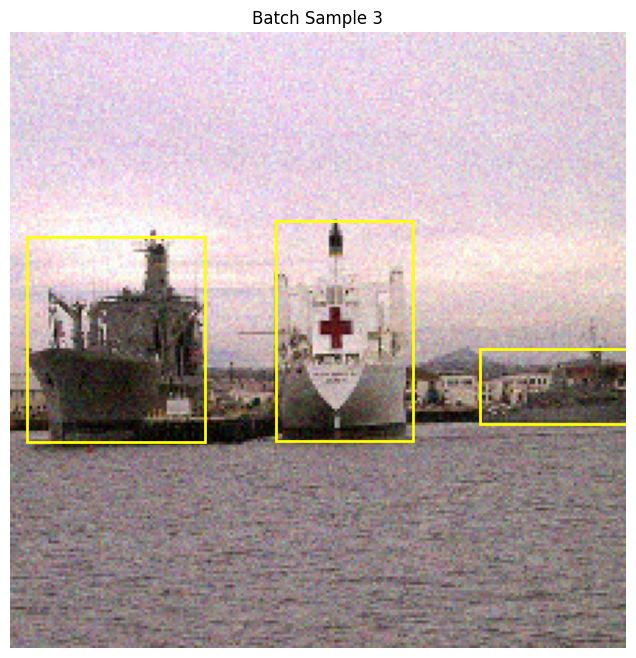

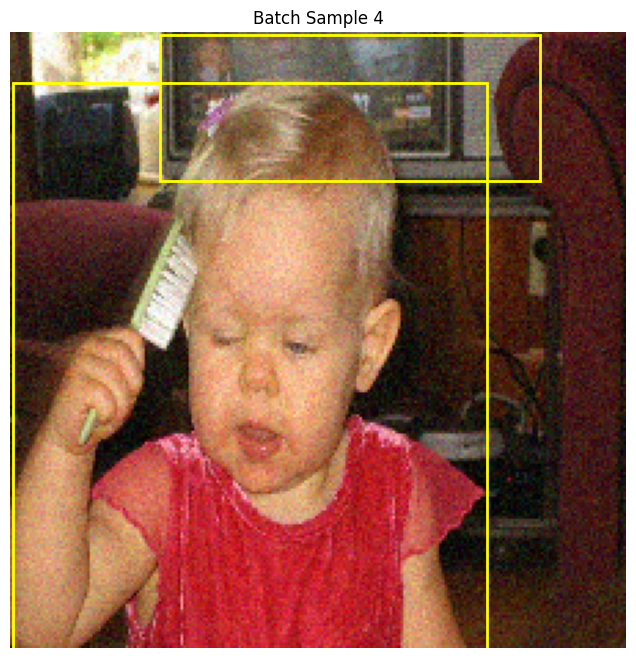

Training data pipeline test complete.


In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Create a training pipeline instance
train_dataset = data_pipeline_train(gt_file="2007_train.txt", batch_size=4)

print("Testing training data pipeline...")

# Retrieve and display a batch of data to verify
for i, (images_batch, y_tensors_batch) in enumerate(train_dataset.take(1)):
    print(f"Batch {i+1}:")
    print(f"  Images batch shape: {images_batch.shape}")
    print(f"  GT tensors batch shape: {y_tensors_batch.shape}")

    # Visualize images from the batch (with bounding boxes)
    print("Visualizing first 4 samples from the batch...")
    for j in range(min(4, images_batch.shape[0])):
        fig, ax = plt.subplots(1, figsize=(8, 8))
        image_np = images_batch[j].numpy()
        ax.imshow(image_np)

        # Calculate cell dimensions in pixels for coordinate conversion
        cell_width_px = IMG_W / S
        cell_height_px = IMG_H / S

        # Iterate through the grid to find objects
        for grid_y in range(S):
            for grid_x in range(S):
                confidence = y_tensors_batch[j, grid_y, grid_x, 20]
                if confidence > 0.0:
                    x_in_cell_rel, y_in_cell_rel, w_rel_img, h_rel_img = y_tensors_batch[j, grid_y, grid_x, 21:25]

                    abs_x_center = (grid_x + x_in_cell_rel) * cell_width_px
                    abs_y_center = (grid_y + y_in_cell_rel) * cell_height_px
                    abs_width = w_rel_img * IMG_W
                    abs_height = h_rel_img * IMG_H

                    x_min_px = abs_x_center - (abs_width / 2)
                    y_min_px = abs_y_center - (abs_height / 2)

                    rect_gt = patches.Rectangle(
                        (x_min_px, y_min_px),
                        abs_width, abs_height,
                        linewidth=2, edgecolor='yellow', facecolor='none'
                    )
                    ax.add_patch(rect_gt)

        ax.set_title(f'Batch Sample {j+1}')
        ax.axis('off')
        plt.show()

print("Training data pipeline test complete.")

In [11]:
def data_pipeline_val(gt_file="2007_val.txt", img_dir="VOCdevkit/VOC2007/JPEGImages", batch_size=32):
    # Create a TensorFlow Dataset from the generator
    dataset = tf.data.Dataset.from_generator(
        lambda: data_generator(gt_file=gt_file, img_dir=img_dir),
        output_types=(tf.float32, tf.float32),
        output_shapes=(
            tf.TensorShape([IMG_H, IMG_W, 3]),
            tf.TensorShape([S, S, 5 * B + C])
        )
    )

    # (a) Resize is already handled by data_generator to IMG_H x IMG_W
    # (b) Make up batches
    dataset = dataset.batch(batch_size)

    # Prefetch to improve performance
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

    return dataset

#### Test the validation data pipeline

Testing validation data pipeline...
Batch 1:
  Images batch shape: (4, 224, 224, 3)
  GT tensors batch shape: (4, 7, 7, 25)
Visualizing first 4 samples from the batch...


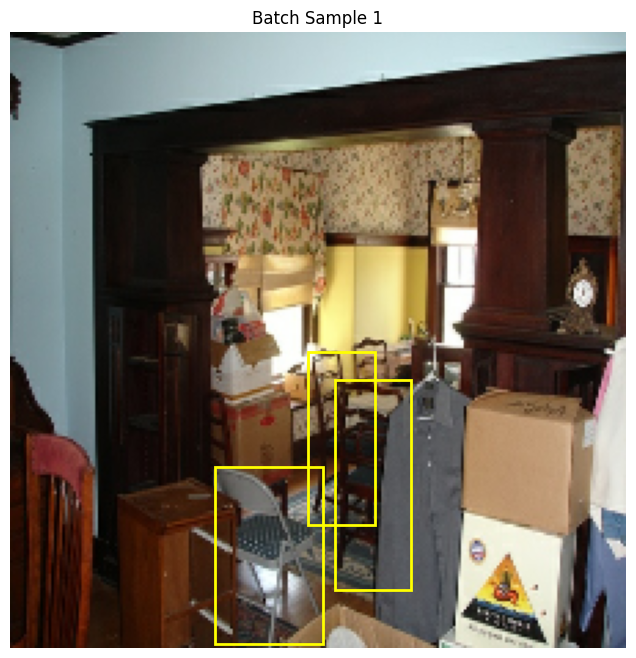

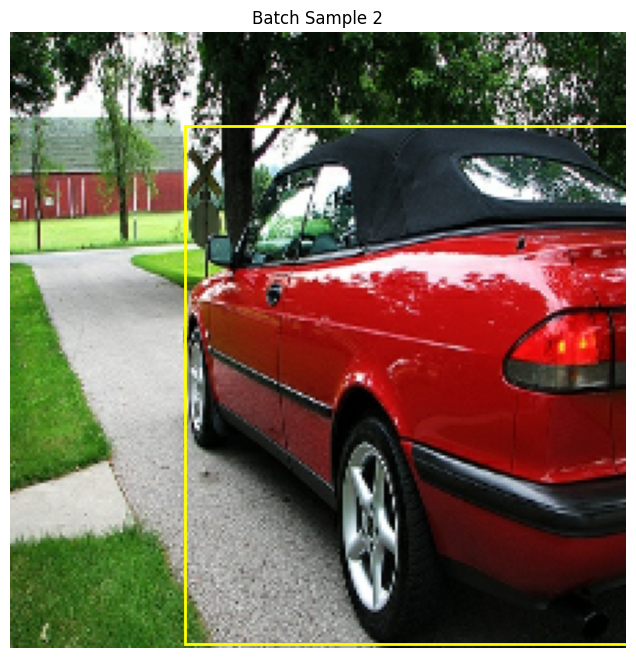

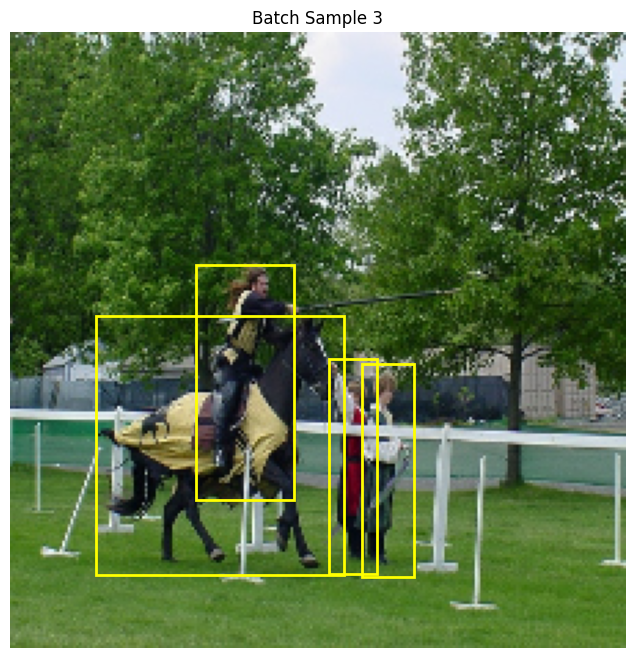

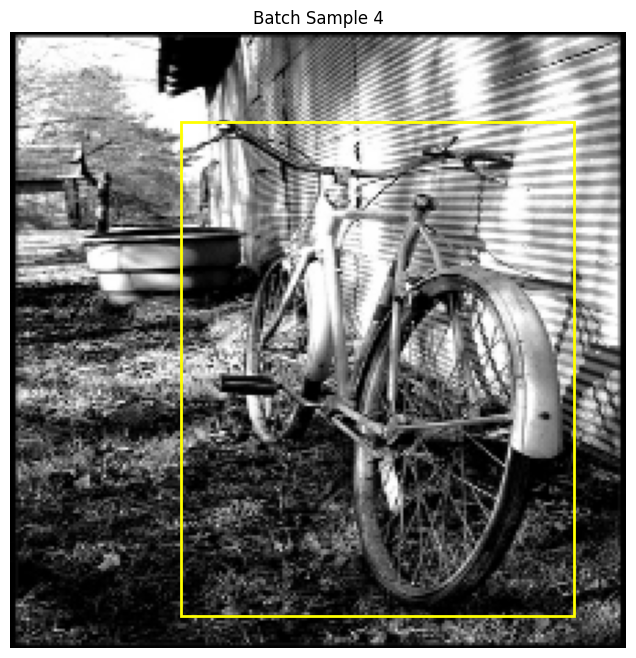

Validation data pipeline test complete.


In [12]:
# Create a validation pipeline instance
val_dataset = data_pipeline_val(gt_file="2007_val.txt", batch_size=4)

print("Testing validation data pipeline...")

# Retrieve and display a batch of data to verify
for i, (images_batch, y_tensors_batch) in enumerate(val_dataset.take(1)):
    print(f"Batch {i+1}:")
    print(f"  Images batch shape: {images_batch.shape}")
    print(f"  GT tensors batch shape: {y_tensors_batch.shape}")

    # Visualize images from the batch (with bounding boxes)
    print("Visualizing first 4 samples from the batch...")
    for j in range(min(4, images_batch.shape[0])):
        fig, ax = plt.subplots(1, figsize=(8, 8))
        image_np = images_batch[j].numpy()
        ax.imshow(image_np)

        # Calculate cell dimensions in pixels for coordinate conversion
        cell_width_px = IMG_W / S
        cell_height_px = IMG_H / S

        # Iterate through the grid to find objects
        for grid_y in range(S):
            for grid_x in range(S):
                confidence = y_tensors_batch[j, grid_y, grid_x, 20]
                if confidence > 0.0:
                    x_in_cell_rel, y_in_cell_rel, w_rel_img, h_rel_img = y_tensors_batch[j, grid_y, grid_x, 21:25]

                    abs_x_center = (grid_x + x_in_cell_rel) * cell_width_px
                    abs_y_center = (grid_y + y_in_cell_rel) * cell_height_px
                    abs_width = w_rel_img * IMG_W
                    abs_height = h_rel_img * IMG_H

                    x_min_px = abs_x_center - (abs_width / 2)
                    y_min_px = abs_y_center - (abs_height / 2)

                    rect_gt = patches.Rectangle(
                        (x_min_px, y_min_px),
                        abs_width, abs_height,
                        linewidth=2, edgecolor='yellow', facecolor='none'
                    )
                    ax.add_patch(rect_gt)

        ax.set_title(f'Batch Sample {j+1}')
        ax.axis('off')
        plt.show()

print("Validation data pipeline test complete.")

## 2. Modeling and Training (40 points)
**Exercise 2.1 (10 points)**

YOLO V1 network is not trained from scratch. Pretaining step and fine-tuning step are combined sequentially to train the entire YOLO network in the literature. This procedure contains the following steps:

1. Take a network, e.g. VGG16, ResNet34, which is already trained on a given data set (usually a large data set). Here, we take VGG16 network.
2. Take the backbone of VGG16 network and fix all of its parameters.
3. Add a head to the backbone. The head contains only convolutions. Now the backbone and the head constitute a YOLO network. The parameters of the head are trainable.
4. Train the parameters of the head, while keep the parameters of the backbone fixed.  

Tasks:
1. Call tf.keras.applications.vgg16.VGG16() to download a pretrained backbone of VGG16 on data set "imagenet".

    - The input dimension of the backbone is $224*224*3$. The output dimension is $7*7*M$.

2. Fix all trainable parameters of the backbone.

3. Add a head to the backbone. Make sure that the output of heads has dimension 7\*7\*25. As an option, one could use the following structure for the head:  

    - (1) conv, filters= 512, kernel 3\*3, activation='leaky_relu'

    - (2) conv, filters= 512, kernel 3\*3, activation='leaky_relu'

    - (3) conv, filters= ?, kernel 3\*3, activation='?'. The type of the activation should be selected such that all elements of the output tensor belong to [0, 1].  

4. create the model and print out model.summary()




In [13]:
import tensorflow as tf
from keras.layers import Conv2D, MaxPooling2D, Input
from keras.models import Model
from keras.layers import LeakyReLU

def modeling(img_h, img_w, img_c, num_class):
    x_input = Input(shape=(img_h, img_w, img_c))

    # 1. Download a pretrained backbone of VGG16 on data set "imagenet"
    # The input dimension of the backbone is 224*224*3. The output dimension is 7*7*M.
    vgg16_backbone = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(img_h, img_w, img_c))

    # Use the output of the last pooling layer of VGG16 (which should be 7x7x512 for 224x224 input)
    x = vgg16_backbone(x_input)

    # 2. Fix all trainable parameters of the backbone.
    for layer in vgg16_backbone.layers:
        layer.trainable = False

    # 3. Add a head to the backbone. Output has dimension 7*7*25.
    # (1) conv, filters= 512, kernel 3*3, activation='leaky_relu'
    x = Conv2D(512, (3, 3), padding='same', activation=LeakyReLU(alpha=0.1))(x)
    # (2) conv, filters= 512, kernel 3*3, activation='leaky_relu'
    x = Conv2D(512, (3, 3), padding='same', activation=LeakyReLU(alpha=0.1))(x)
    # (3) conv, filters= ?, kernel 3*3, activation='?'. The type of the activation should be selected such that all elements of the output tensor belong to [0, 1].
    # The output tensor has shape (S, S, 5*B + C). Here S=7, B=1, C=20, so 7x7x25.
    # The activation should produce values between 0 and 1. 'sigmoid' is suitable for this.
    # The number of filters for the last layer should be 5*B + C = 5*1 + 20 = 25.
    y = Conv2D(5 * B + C, (1, 1), activation='sigmoid')(x) # Using 1x1 conv for the final prediction layer

    # Create the model
    model = Model(inputs=x_input, outputs=y)

    # 4. Print out model.summary()
    model.summary()

    return model


In [15]:
# Instantiate the model and print its summary
# Define constants for modeling function from previously defined global constants
# S, B, C, IMG_W, IMG_H are already defined globally

model = modeling(IMG_H, IMG_W, 3, C) # img_h, img_w, img_c, num_class


/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 25)       │        12,825 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,447,129 (74.18 MB)

 Trainable params: 4,732,441 (18.05 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

**Exercise 2.2 Loss function (10 points)**
1. Please implement this loss function. $\lambda _{coord}$ = 100,  $\lambda _{noobj}=1$, shown in the lecture slide. For debugging purpose (optional), it is recommended to return the 3 parts of the loss function separately, namely loss_for_xywh, loss_for_confidence, loss_for_class.

2. For the following y_gt and y_pred, please compute the value of this loss function (to check the correctness of your implementation).

In [ ]:
import numpy as np
y_pred = np.ones((7, 7, 25)) * 0.5

y_gt = np.zeros((7, 7, 25), dtype=np.float32)
y_gt[1, 1, :11] = 1
y_gt[1, 1, 20:25] = [1., 0.758, 0.95, (403-90)/480, (336-78)/364]

def loss_fun(y_pred, y_gt):
        pass

**Exercise 2.3 Training (20 points)**:
We have built all important elements of a training program for YOLO. Now let us combine them together to obtain a complete training program.

Tasks:
1. Write a training program to train YOLO model for in total $N$ steps. Choose the proper learning rate such that the loss function can be effectively reduced.

2. For each 100 training steps,

    - Print out (a) the average loss function for the last 100 steps.

    - Please print all string-based info into a txt file. It is recommended to use logging package (see below).

3. After the entire training is finished, evaluate the average loss function on val data (2007_val.txt).

4. Check the values of non-trainable variables of the VGG16 backbone. Their values should be kept the same during the training process. An easy way is to check the summation of non-trainable variables by calling sum_of_vars(model.non_trainable_variables).

Advice:
    YOLO V1 is not a trivial system, and training it is complicated. Any mistakes in the data pipeline, in the modeling and in the selection of training parameters may lead to undesired training results. To debug the training process, my suggestions:

1. Visualize the images ($224*224*3$) that are fed directly to network.

2. Visualize the output tensor by visualizing the decoded bounding boxes. Step 1 and 2 make sure that the network gets the correct "data".

3. Obverse the loss function for its three sub-parts, separately. If some parts do not get reduced, find out the reason.

4. Adjust the learning rate.

5. Check the transformation between output tensor and the bouding box label. It is often that this encoding-decoding process is wrong.

6. If over-fitting, try to reduce the model complexity or do early stoping.

In [ ]:
# functions, which could be used (optional)
import logging
def init_logging(log_path=None, mode='w', level=logging.INFO):
    if not log_path:
        log_path = os.path.join(os.getcwd(), 'filename.log')
    if level is None:
        level = logging.INFO
    format = '%(asctime)s - %(name)s - %(levelname)s : %(message)s'
    handlers = [logging.FileHandler(log_path, mode=mode), logging.StreamHandler()]
    logging.basicConfig(level=level, format=format, handlers=handlers)
    logging.info(f'log_path: {log_path}')


def sum_of_vars(var):
    # var = model.trainable_variables or model.non_trainable_variables
    value = 0
    num = 0
    for t in var:
        value += np.sum(t.numpy())
        num += np.prod(t.shape.as_list())

    return value, num

In [ ]:
# Solution example. Feel free to change it
import logging
import tensorflow as tf
import numpy as np

work_dir = r''

# logging
logging_path = os.path.join(work_dir, 'logging.log')
init_logging(logging_path, level=logging.DEBUG)
logger = logging.getLogger(__name__)


class YOLOModel(tf.keras.Model):
    def __init__(self, work_dir):
        super().__init__()
        self.input_w = 224
        self.input_h = 224
        self.input_c = 3
        self.num_class = 20

        self._setup_layers()
        self._setup_metrics()

        self.work_dir = work_dir

    @property
    def metrics(self):
        return [self._loss_metric, self._loss_metric_existence, self._loss_metric_xywh, self._loss_metric_class]

    def _setup_metrics(self):
        self._loss_metric = tf.keras.metrics.Mean(name='loss_mean')
        self._loss_metric_existence = tf.keras.metrics.Mean(name='loss_mean_existence')
        self._loss_metric_xywh = tf.keras.metrics.Mean(name='loss_mean_xywh')
        self._loss_metric_class = tf.keras.metrics.Mean(name='loss_mean_class')

    def _metrics_reset(self):
        for m in self.metrics:
            m.reset_states()

    def _update_metrics(self, loss, loss_obj_existence, loss_xywh, loss_class):
        self._loss_metric.update_state(loss)
        self._loss_metric_existence.update_state(loss_obj_existence)
        self._loss_metric_xywh.update_state(loss_xywh)
        self._loss_metric_class.update_state(loss_class)


    def _setup_layers(self):
        self.cnn = modeling(...)

    def train(self, data_train, steps, delta_steps=100):
        for step, (image, y_label) in enumerate(data_train):
            # compute loss and update gradients
            # todo

            # update metrics
            self._update_metrics(loss, loss_obj_existence, loss_xywh, loss_class)

            if step % delta_steps == 0:
                self._metrics_reset()
                self._data_visualize() #optional: only for debug
                self._savemodel()


            if step >= steps:
                break

        print(f'done: total_step {step}, finish')


    def loss_fun(self, y_pred, y_label):
        # re-use the code in e3.1
        raise NotImplemented

    def data_visualize(self, data):
        raise NotImplemented

    def save_model():
        raise NotImplemented

    def load_model():
        raise NotImplemented


**Exercise 2.4 NMS and Prediction (Not mandatory, 10 points)**:
The predictions of YOLO model may contain multiple bounding boxes for the same object in the image. Non-Maximum Suppression (NMS) is a method to clean up redundant bounding boxes by checking Intersection over Union (IoU).

Tasks:
1. Please implement or call any NMS algorithm. The algorithm takes the positions of bounding boxes, their confidences and an IoU threshold. It outputs the positions of bounding boxes after clean-up.

2. Please test the developed NMS algorithm on the prediction of any selected image, which is not seen by the network.

3. Visualize the predicted bounding boxes with and without NMS.

In [ ]:
def non_max_suppression(bb_labels, bb_confidences, iou_threshold):
    pass

# prediciton
y = yolo_model(image, training=False)

